In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/yashusinghal/electric-vehicle-population-dataset/Electric_Vehicle_Population_Data.csv


In [2]:
import pandas as pd

data = pd.read_csv('/kaggle/input/datasets/yashusinghal/electric-vehicle-population-dataset/Electric_Vehicle_Population_Data.csv')

data.head()

,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Base MSRP,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract
0,3C3CFFGE4E,Yakima,Yakima,WA,98902.0,2014,FIAT,500,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,87,0,14.0,1593721,POINT (-120.524012 46.5973939),PACIFICORP,5.307700e+10
1,5YJXCBE40H,Thurston,Olympia,WA,98513.0,2017,TESLA,MODEL X,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,200,0,2.0,257167501,POINT (-122.817545 46.98876),PUGET SOUND ENERGY INC,5.306701e+10
2,3MW39FS03P,King,Renton,WA,98058.0,2023,BMW,330E,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,20,0,11.0,224071816,POINT (-122.1298876 47.4451257),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303303e+10
3,7PDSGABA8P,Snohomish,Bothell,WA,98012.0,2023,RIVIAN,R1S,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0,0,21.0,260084653,POINT (-122.1873 47.820245),PUGET SOUND ENERGY INC,5.306105e+10
4,5YJ3E1EB8L,King,Kent,WA,98031.0,2020,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,322,0,33.0,253771913,POINT (-122.2012521 47.3931814),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303303e+10


FIRST 5 ROWS
   VIN (1-10)     County     City State  Postal Code  Model Year    Make  \
0  3C3CFFGE4E     Yakima   Yakima    WA      98902.0        2014    FIAT   
1  5YJXCBE40H   Thurston  Olympia    WA      98513.0        2017   TESLA   
2  3MW39FS03P       King   Renton    WA      98058.0        2023     BMW   
3  7PDSGABA8P  Snohomish  Bothell    WA      98012.0        2023  RIVIAN   
4  5YJ3E1EB8L       King     Kent    WA      98031.0        2020   TESLA   

     Model                   Electric Vehicle Type  \
0      500          Battery Electric Vehicle (BEV)   
1  MODEL X          Battery Electric Vehicle (BEV)   
2     330E  Plug-in Hybrid Electric Vehicle (PHEV)   
3      R1S          Battery Electric Vehicle (BEV)   
4  MODEL 3          Battery Electric Vehicle (BEV)   

   Clean Alternative Fuel Vehicle (CAFV) Eligibility  Electric Range  \
0            Clean Alternative Fuel Vehicle Eligible              87   
1            Clean Alternative Fuel Vehicle Eligible         

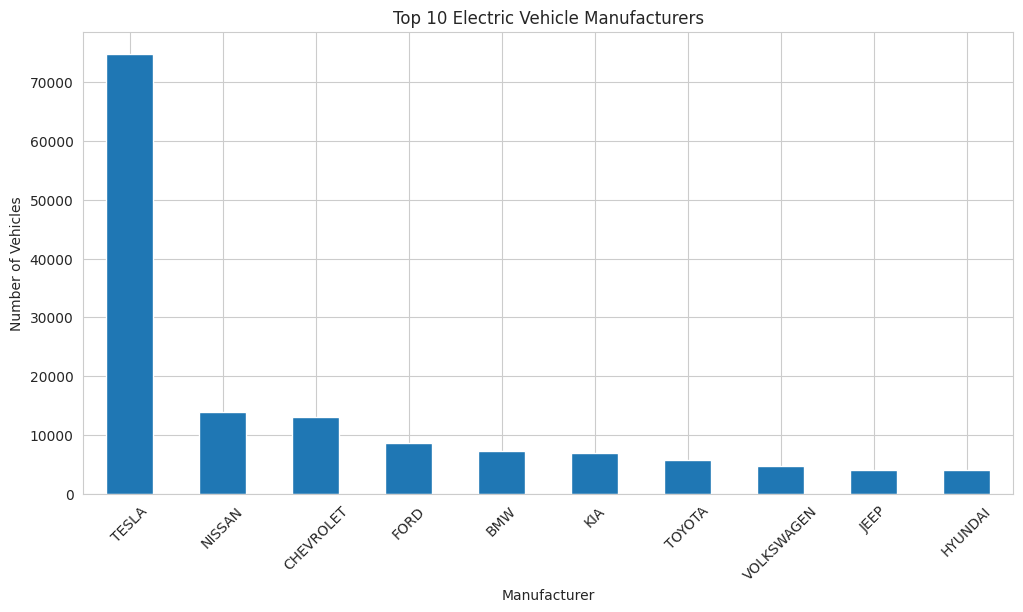

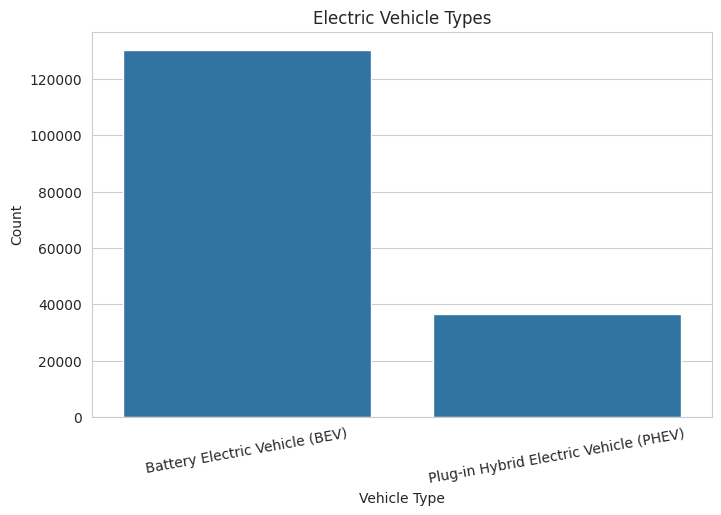

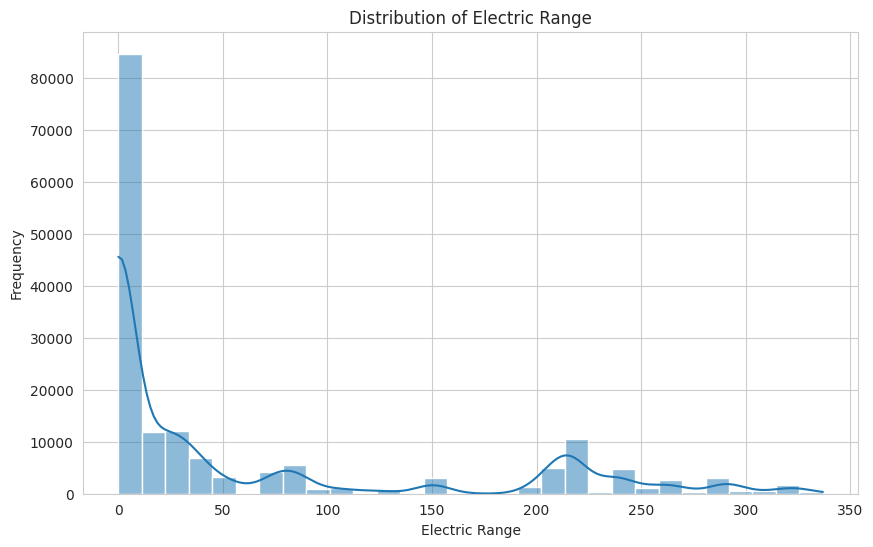

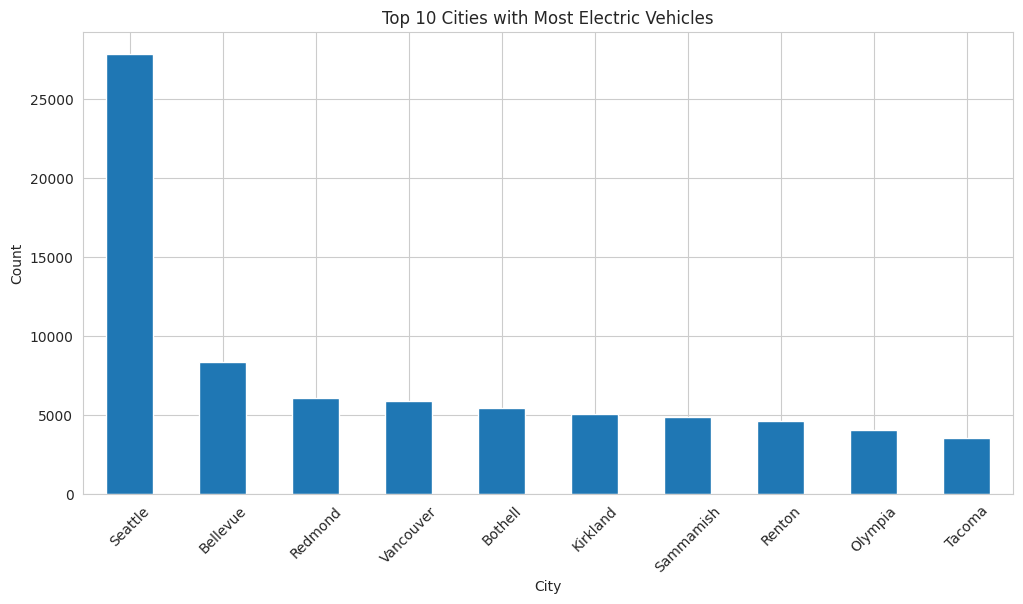

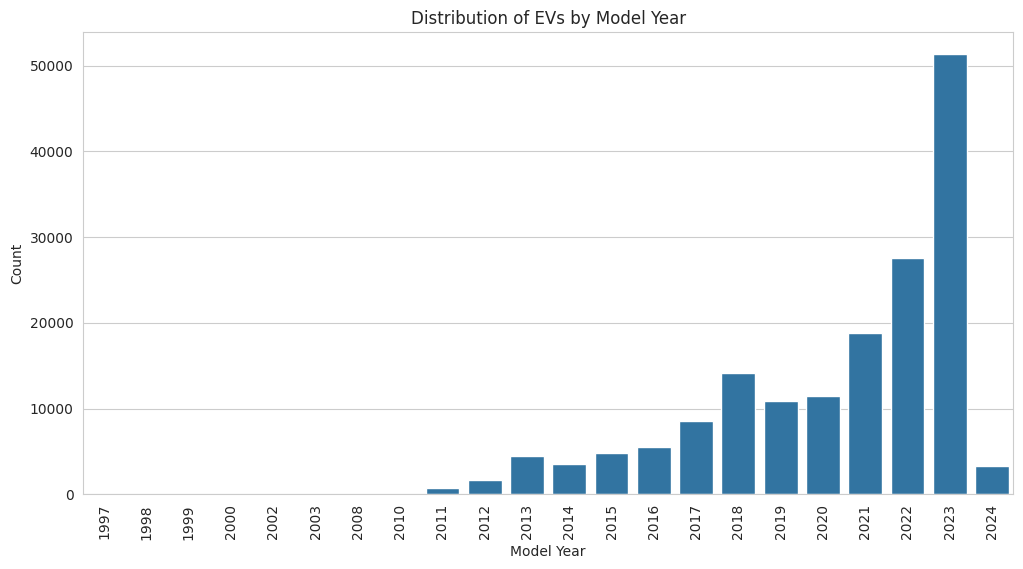

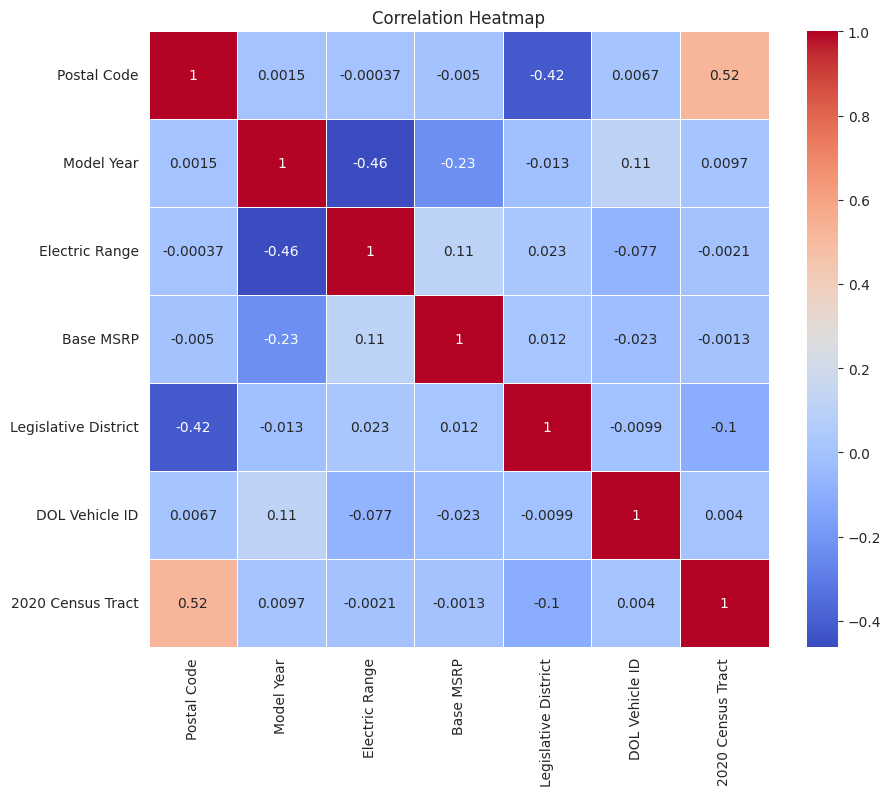

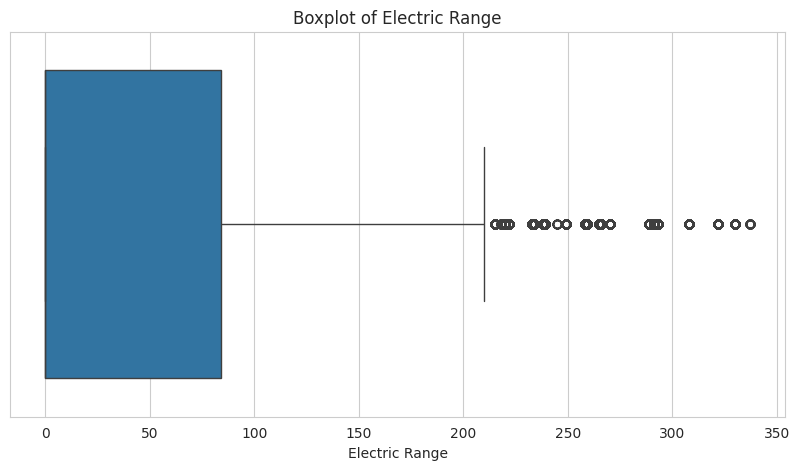


================ EDA INSIGHTS ================

1. The dataset contains information about electric vehicles.
2. Some manufacturers dominate the EV market.
3. Battery Electric Vehicles are more common.
4. Electric range varies significantly across vehicles.
5. Certain cities have a higher concentration of EVs.
6. Correlation analysis helps identify relationships among numerical variables.

================ END OF PROJECT ================



In [3]:
# ============================================
# Exploratory Data Analysis (EDA) Project
# Electric Vehicle Population Dataset
# ============================================

# ---------- IMPORT LIBRARIES ----------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)

# ---------- LOAD DATASET ----------
data = pd.read_csv(
    '/kaggle/input/datasets/yashusinghal/electric-vehicle-population-dataset/Electric_Vehicle_Population_Data.csv'
)

# ---------- FIRST LOOK ----------
print("FIRST 5 ROWS")
print(data.head())

print("\nDATASET SHAPE")
print(data.shape)

print("\nCOLUMN NAMES")
print(data.columns)

print("\nDATA TYPES")
print(data.dtypes)

print("\nDATASET INFO")
print(data.info())

# ---------- MISSING VALUES ----------
print("\nMISSING VALUES")
print(data.isnull().sum())

# ---------- REMOVE DUPLICATES ----------
data.drop_duplicates(inplace=True)

print("\nSHAPE AFTER REMOVING DUPLICATES")
print(data.shape)

# ---------- STATISTICAL SUMMARY ----------
print("\nSTATISTICAL SUMMARY")
print(data.describe())

# ---------- UNIQUE VALUES ----------
print("\nTOP VEHICLE MAKES")
print(data['Make'].value_counts().head(10))

print("\nELECTRIC VEHICLE TYPES")
print(data['Electric Vehicle Type'].value_counts())

# ============================================
# VISUALIZATIONS
# ============================================

sns.set_style("whitegrid")

# ---------- TOP 10 EV MANUFACTURERS ----------
plt.figure(figsize=(12,6))

data['Make'].value_counts().head(10).plot(
    kind='bar'
)

plt.title('Top 10 Electric Vehicle Manufacturers')
plt.xlabel('Manufacturer')
plt.ylabel('Number of Vehicles')
plt.xticks(rotation=45)

plt.show()

# ---------- ELECTRIC VEHICLE TYPE ----------
plt.figure(figsize=(8,5))

sns.countplot(
    x='Electric Vehicle Type',
    data=data
)

plt.title('Electric Vehicle Types')
plt.xlabel('Vehicle Type')
plt.ylabel('Count')

plt.xticks(rotation=10)

plt.show()

# ---------- ELECTRIC RANGE DISTRIBUTION ----------
plt.figure(figsize=(10,6))

sns.histplot(
    data['Electric Range'],
    bins=30,
    kde=True
)

plt.title('Distribution of Electric Range')
plt.xlabel('Electric Range')
plt.ylabel('Frequency')

plt.show()

# ---------- TOP 10 CITIES WITH MOST EVs ----------
plt.figure(figsize=(12,6))

data['City'].value_counts().head(10).plot(
    kind='bar'
)

plt.title('Top 10 Cities with Most Electric Vehicles')
plt.xlabel('City')
plt.ylabel('Count')

plt.xticks(rotation=45)

plt.show()

# ---------- MODEL YEAR DISTRIBUTION ----------
plt.figure(figsize=(12,6))

sns.countplot(
    x='Model Year',
    data=data,
    order=sorted(data['Model Year'].unique())
)

plt.title('Distribution of EVs by Model Year')
plt.xlabel('Model Year')
plt.ylabel('Count')

plt.xticks(rotation=90)

plt.show()

# ---------- CORRELATION HEATMAP ----------
numeric_data = data.select_dtypes(include=np.number)

correlation_matrix = numeric_data.corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    linewidths=0.5
)

plt.title('Correlation Heatmap')

plt.show()

# ---------- BOXPLOT FOR ELECTRIC RANGE ----------
plt.figure(figsize=(10,5))

sns.boxplot(
    x=data['Electric Range']
)

plt.title('Boxplot of Electric Range')

plt.show()

# ============================================
# INSIGHTS
# ============================================

print("\n================ EDA INSIGHTS ================\n")

print("1. The dataset contains information about electric vehicles.")
print("2. Some manufacturers dominate the EV market.")
print("3. Battery Electric Vehicles are more common.")
print("4. Electric range varies significantly across vehicles.")
print("5. Certain cities have a higher concentration of EVs.")
print("6. Correlation analysis helps identify relationships among numerical variables.")

print("\n================ END OF PROJECT ================\n")